<a href="https://colab.research.google.com/github/Alenushka2013/ML_for_people_tasks/blob/main/SQL_HW%E2%84%963_Python_%2B_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Завдання на використання SQL в Python

1.Встановіть бібліотеку `mysql-connector-python` через pip aбо через conda.

In [1]:
#!pip install mysql-connector-python

In [2]:
#! pip list | grep mysql-connector-python

In [3]:
import mysql.connector
from mysql.connector.connection import MySQLConnection
import datetime

2.В змінній `con` створіть підключення до бази даних employees за аналогією того, як це робилось в лекції:

In [4]:
con = mysql.connector.connect(user='student', password='IAmLearningSQL',
                              host='shinkansen.proxy.rlwy.net',
                              database='employees',
                              port= 50507)

3.Виберіть максимальну і мінімальну дати найму співробітників використовуючи `con.cursor()`. Аби отримати результати в кінці, виконайте `cursor.fetchall()`.

In [5]:
cursor = con.cursor(buffered=True)
sql = "SELECT * FROM employees LIMIT 5"
cursor.execute(sql)

columns = cursor.column_names
print(f"{' | '.join(columns)}")
print("-" * 50)

for row in cursor:
    print(row)

emp_no | birth_date | first_name | last_name | gender | hire_date
--------------------------------------------------
(10001, datetime.date(1953, 9, 2), 'Georgi', 'Facello', 'M', datetime.date(1986, 6, 26))
(10002, datetime.date(1964, 6, 2), 'Bezalel', 'Simmel', 'F', datetime.date(1985, 11, 21))
(10003, datetime.date(1959, 12, 3), 'Parto', 'Bamford', 'M', datetime.date(1986, 8, 28))
(10004, datetime.date(1954, 5, 1), 'Chirstian', 'Koblick', 'M', datetime.date(1986, 12, 1))
(10005, datetime.date(1955, 1, 21), 'Kyoichi', 'Maliniak', 'M', datetime.date(1989, 9, 12))


In [6]:
sql = "SELECT MAX(hire_date), MIN(hire_date) FROM employees"
cursor.execute(sql)
results = cursor.fetchall()
print(results)

[(datetime.date(2000, 1, 28), datetime.date(1985, 1, 1))]


Очікуваний результат:  
    `[(datetime.date(2000, 1, 28), datetime.date(1985, 1, 1))]`

4.Давайте зберемо інформацію про останню ЗП кожного співробіткника в базі. З використанням `con.cursor()` виберіть з таблиці `salaries` для кожного співробітника його номер, останню в базі даних (тобто ту, що відповідає найновішій `to_date`) ЗП, та значення `from_date`, `to_date` для цієї ЗП.

Результати запишіть у pandas DataFrame, який збережіть у змінну `res`. Як взяти з курсора назви колонок - вже наведено. На екран виведіть назви колонок в змінній `res`, розмір цього датафрейму та перші 3 записи в ньому.

УВАГА! Зверніть увагу, що ЗП може оновлюватись протягом одного дня, тобто є випадки, коли апдейт ЗП був в певний день, скажімо 2001-01-01 і потім стався ще один апдейт ЗП цьому співробітнику цього самого дня. Запит має це враховувати.
Також, теоретично ЗП може бути зменшена. Тож, брати дату з максимальною ЗП буде неправильно з точки зору бізнес логіки. Треба саме останнє історичне значення ЗП кожного співробітника.

In [7]:
sql = "select * from salaries limit 5"
cursor.execute(sql)

columns = cursor.column_names
print(f"{' | '.join(columns)}")
print("-" * 50)

for row in cursor:
    print(row)

emp_no | salary | from_date | to_date
--------------------------------------------------
(10001, 60117, datetime.date(1986, 6, 26), datetime.date(1987, 6, 26))
(10001, 62102, datetime.date(1987, 6, 26), datetime.date(1988, 6, 25))
(10001, 66074, datetime.date(1988, 6, 25), datetime.date(1989, 6, 25))
(10001, 66596, datetime.date(1989, 6, 25), datetime.date(1990, 6, 25))
(10001, 66961, datetime.date(1990, 6, 25), datetime.date(1991, 6, 25))


In [8]:
import pandas as pd

sql = """select s.emp_no, s.salary, s.from_date, s.to_date
         from salaries s
         inner join (
            select emp_no, max(to_date) as max_date
            from salaries
            group by emp_no
          ) last_date
          ON s.emp_no = last_date.emp_no AND s.to_date = last_date.max_date
          """

cursor.execute(sql)
results = cursor.fetchall()

columns = [col[0] for col in cursor.description]
res = pd.DataFrame(results, columns=columns)

print('назви колонок:', res.columns)
print('розмір датафрейму:', res.shape)
display(res.head(3))

назви колонок: Index(['emp_no', 'salary', 'from_date', 'to_date'], dtype='object')
розмір датафрейму: (300180, 4)


,emp_no,salary,from_date,to_date
0,10001,88958,2002-06-22,9999-01-01
1,10002,72527,2001-08-02,9999-01-01
2,10003,43311,2001-12-01,9999-01-01


In [9]:
# field_names = [i[0] for i in cursor.description]

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1lNvzbAebtkj3C2v-I5AE6HkMH8MTI1kA)

5.В утвореній вибірці в змінній `res` скільки значень `to_date` рівні `9999-01-01`, а скільки - ні? Увага! Для виконання цього завдання важливо розуміти, який тип даних у значень колонки `to_date`. Зʼясуйте це, і потім напишіть фільтр для виводу потрібного результату.

In [10]:
res.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300180 entries, 0 to 300179
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   emp_no     300180 non-null  int64 
 1   salary     300180 non-null  int64 
 2   from_date  300180 non-null  object
 3   to_date    300180 non-null  object
dtypes: int64(2), object(2)
memory usage: 9.2+ MB


In [11]:
target_date = datetime.date(9999, 1, 1)

print(f"Кількість значень 9999-01-01: {(res.to_date == target_date).sum()}")
print(f"Кількість інших значень: {(res.to_date != target_date).sum()}")

Кількість значень 9999-01-01: 240124
Кількість інших значень: 60056


6.Виведіть візуально розподіл (гістограму) зарплат співробітників, які досі працюють в компанії, використовуючи результат попереднього завдання. Співробітниками, які досі працюють в компанії вважаємо тих, в кого to_date має значення 9999-01-01. Обовʼязково підпишіть графік і вісі.

Ці три завдання - приклад, як нам може бути зручно витягнути дані з бази певним запитом, а потім використати витягнуту вибірку у Python для подальшого аналізу.

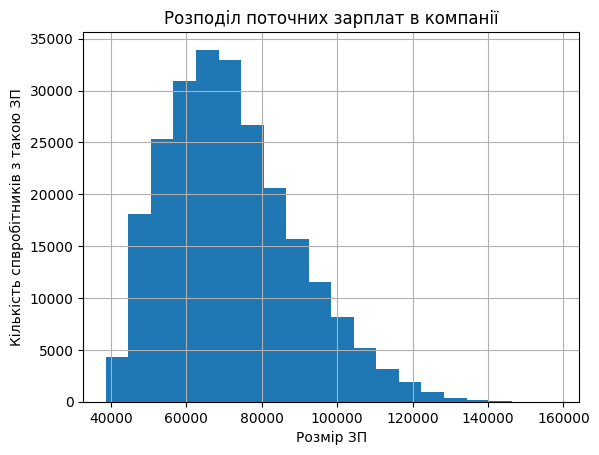

In [12]:
import matplotlib.pyplot as plt

res_work_now = res[res.to_date == target_date]

res_work_now.salary.hist(bins = 20)
plt.title('Розподіл поточних зарплат в компанії')
plt.xlabel("Розмір ЗП")
plt.ylabel("Кількість спвробітників з такою ЗП")
plt.show()

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1j8MHLC1E0revbQLM9B0UJs6tVEgoWhmK)

НЕ ЗАБУВАЄМО ЗАКРИТИ ПІДКЛЮЧЕННЯ ДО БАЗИ :)

In [13]:
con.close()